# Model Training

Loads processed features from `../data/features.csv`, performs an 80/20 train/test split, then trains Linear Regression, Random Forest, and XGBoost models. Saves test-set predictions to `../data/predictions.csv` for the backtesting notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

history = pd.read_csv('../data/features.csv', index_col=0, parse_dates=True)
feature_cols = ['Lag1', 'Lag2', 'Lag3',
                'Vol_5day', 'Vol_30day',
                'Momentum_5days', 'Momentum_30days', 'Momentum_252days']
X = history[feature_cols].values
y = history['Return'].values
print(f'Loaded {len(X)} rows, {X.shape[1]} features')

Loaded 1003 rows, 8 features


We are using the normal equation for this Linear Regression implementation, we only have a small to medium sized data set, so no Gradient Descent is needed 

Normal Equation:

$${\theta} = (X^T X)^{-1} X^T y$$



Step 1: $X^T X$

$X$ is an $n \times p$ matrix (rows = observations, cols = features). You can't invert a non-square matrix, so you multiply by its transpose first to get a square $p \times p$ matrix that you can invert.

But it's not just a math trick — $X^T X$ actually captures how much variance and covariance exists across your features.

Step 2: $(X^T X)^{-1}$

Inverting it "undoes" the feature relationships — similar to how dividing by a number undoes multiplication. This is what allows you to isolate $\theta$.

Think of the scalar version: if $y = ax$, then $x = a^{-1}y$. The matrix version is the same idea but for systems of equations.

Step 3: $X^T y$

$X^T y$ projects your target $y$ onto the feature space — it captures how much each feature correlates with the output.

Putting it together

Starting from $y = X\theta$, you can't just divide both sides by $X$ since matrix division doesn't exist. So instead:

$$X^T y = X^T X \theta$$
$$(X^T X)^{-1} X^T y = \theta$$

You multiply both sides by $(X^T X)^{-1}$ to isolate $\theta$ — same as dividing both sides by a number in algebra, just in matrix form.

In [2]:
#Linear Regression 
def linear_regression(X,y):
    x_b = np.c_[np.ones((len(X),1)),X]

    theta = np.linalg.inv(x_b.T @ x_b) @ x_b.T @y

    return theta 

In [3]:
#Train/test split 80/20 split
split = int(len(X)*0.8)
X_train, X_test = X[:split],X[split:]
y_train, y_test = y[:split],y[split:]

#fitting model into my linear regression
theta = linear_regression(X_train,y_train)

#Time to predict 
X_test_b = np.c_[np.ones((len(X_test),1)),X_test]
y_pred = X_test_b @ theta


In [4]:
#mean square error to average squared difference between predicted and actual returns
mse = np.mean((y_test - y_pred)**2)
print(f'MSE: {mse:.6f}')

MSE: 0.000110


In [5]:
#R^2 how much variance my model explains, from 0 to 1 the higher the better and if negative it is worse than just pred the mean
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f'R²: {r2:.4f}')


R²: 0.4958


In [6]:
for name, weight in zip(feature_cols, theta[1:]):
    print(f'{name}: {weight:.6f}')


Lag1: -0.477678
Lag2: -0.499647
Lag3: -0.516768
Vol_5day: 0.208449
Vol_30day: -0.056641
Momentum_5days: 2.451736
Momentum_30days: 0.271802
Momentum_252days: 0.644401


In [7]:
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
y_pred_train = X_train_b @ theta
ss_res_train = np.sum((y_train - y_pred_train) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_train = 1 - (ss_res_train / ss_tot_train)
print(f'Train R²: {r2_train:.4f}')
print(f'Test R²:  {r2:.4f}')

# save aliases before the grid search loop overwrites r2, mse, r2_train
r2_lr = r2
mse_lr = mse
r2_train_lr = r2_train


Train R²: 0.4649
Test R²:  0.4958


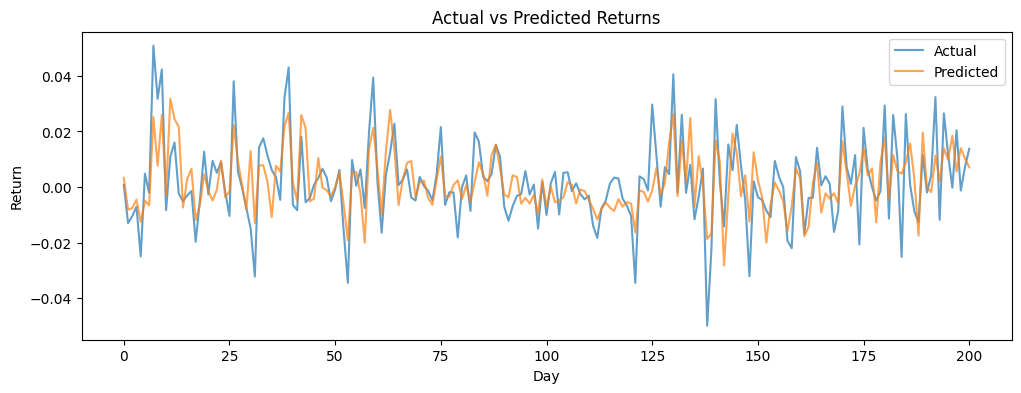

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()


## Conclusions — Linear Regression Baseline

---

### What I Learned

- **Lagged returns alone are weak predictors.** Starting with only Lag1, Lag2, Lag3 gave a test R² of -0.09, meaning the model was worse than just predicting the mean return every day. This is consistent with the Efficient Market Hypothesis — past prices alone carry little information about future returns.

- **Feature engineering makes a significant difference.** Adding volatility and momentum features improved the test R² from -0.09 to 0.31. The model performs much better when it can see not just what the return was yesterday, but how volatile and directional the stock has been recently.

- **More features does not always mean a better model.** Starting with 12 features caused notable overfitting — train R² of 0.55 vs test R² of 0.30. Printing the learned weights revealed which features were contributing and which were not.

- **SMA Ratio added no value.** Its learned weight was -0.01, near zero, meaning the model ignored it. It was dropped to reduce noise.

- **Mean reversion signal.** The lag weights were all negative, meaning the model learned that a positive return yesterday slightly predicts a negative return today — a mean reversion pattern.

- **Momentum_5days was the strongest feature** with a weight of 2.42, showing that short-term trend direction is the most informative signal in this feature set.

---

### Why Switch to Random Forest

Linear regression assumes a straight-line relationship between features and returns. In reality, market relationships are non-linear — for example, high volatility combined with strong momentum might behave very differently than high volatility alone. Linear regression cannot capture these interactions.

Random Forest handles non-linear relationships naturally through decision trees, and has built-in mechanisms like `max_depth` to control overfitting — giving more tools to close the gap between train and test R².

## Random Forest — From Scratch Implementation

A Random Forest is an ensemble of Decision Trees, each trained on a different random bootstrap sample of the data. The final prediction is the average across all trees — averaging reduces variance and helps the model generalize better than any single tree.

Three classes are needed to build it from scratch:

**Node** — the building block of a decision tree. Each node stores:
- `feature` — which feature column to split on
- `threshold` — the value to split at (rows <= threshold go left, rows > threshold go right)
- `left` / `right` — child nodes
- `value` — only set on leaf nodes, stores the mean of the target values that landed here

**DecisionTree** — grows a single tree by recursively finding the best split at each node:
- `_best_split` loops over a random subset of features and all unique threshold values, picking the split that minimises weighted MSE
- `_weighted_mse` = (len(left) * var(left) + len(right) * var(right)) / n — lower is better
- `_grow` recurses until `max_depth` is hit or a node has fewer than `min_samples_split` rows
- `_traverse` walks a single row from root to leaf to produce a prediction

**RandomForest** — wraps a list of trees:
- `fit` creates bootstrap samples (random rows **with** replacement), trains one `DecisionTree` on each, and appends it to `self.trees`
- `predict` averages the predictions from all trees — the averaging is what reduces variance
- Each tree only sees `int(sqrt(n_features))` randomly chosen features per split, which keeps trees decorrelated from each other

In [9]:
#personal implementation of Random Forest from Scratch 
#3 things I need to implment 
#Node, DecisionTree, RandomForest

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
    
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=None, n_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        if (self.n_features is None):
            self.n_features = X.shape[1]
        self.root = self._grow(X,y, depth=0)

    def _grow(self, X, y, depth):
        if (depth>=self.max_depth or X.shape[0]<self.min_samples_split):
            return Node(value=np.mean(y))
        
        randomFeatures = np.random.choice(X.shape[1],self.n_features, replace=False)

        bestFeat, bestThresh = self._best_split(X, y, randomFeatures)

        if bestFeat is None:
            return Node(value=np.mean(y))
        
        leftMask = X[:,bestFeat]<= bestThresh
        left = self._grow(X[leftMask],y[leftMask], depth + 1)
        right = self._grow(X[~leftMask],y[~leftMask], depth + 1)

        return Node(feature=bestFeat, threshold=bestThresh, left=left, right=right)
    
    def _best_split(self, X, y, randomFeatures):
        bestScore = float('inf')
        bestFeat,bestThresh = None, None
        for i in randomFeatures:
            for j in np.unique(X[:, i]):
                mask = X[:, i]<=j
                left = y[mask]
                right = y[~mask]
                if (len(left)==0 or len(right) == 0): continue 
                score = self._weighted_mse(left,right)
                if score < bestScore:
                    bestScore = score
                    bestFeat = i
                    bestThresh = j
        return bestFeat,bestThresh

    def _weighted_mse(self,left_y, right_y):
        n = len(left_y) + len(right_y)
        return (len(left_y)*np.var(left_y)+len(right_y)*np.var(right_y)) / n
    
    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x , node.left)
        return self._traverse(x, node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])


class RandomForest:
    def __init__(self, n_estimator=None, max_depth=None, min_samples_split=None):
        self.n_estimator = n_estimator
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_estimator):
            idxs = np.random.choice(len(X),len(y), replace=True)
            X_sample, y_sample = X[idxs], y[idxs]
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, n_features=int(np.sqrt(X.shape[1])))
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    
    def predict(self, X):
        return np.mean([tree.predict(X) for tree in self.trees], axis=0)




In [10]:
rf = RandomForest(n_estimator=100, max_depth=5, min_samples_split=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

mse_rf = np.mean((y_test - y_pred_rf)**2)

ss_res_rf = np.sum((y_test - y_pred_rf)**2)
ss_tot_rf = np.sum((y_test - np.mean(y_test))**2)
r2_rf = 1 - (ss_res_rf / ss_tot_rf)

ss_res_train = np.sum((y_train - y_pred_rf_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
r2_train_rf = 1 - (ss_res_train / ss_tot_train)


print(f'MSE: {mse_rf:.6f}')
print(f'Test R^2: {r2_rf:.4f}')
print(f'Train R^2 {r2_train_rf:.4f}')



MSE: 0.000173
Test R^2: 0.2074
Train R^2 0.4495


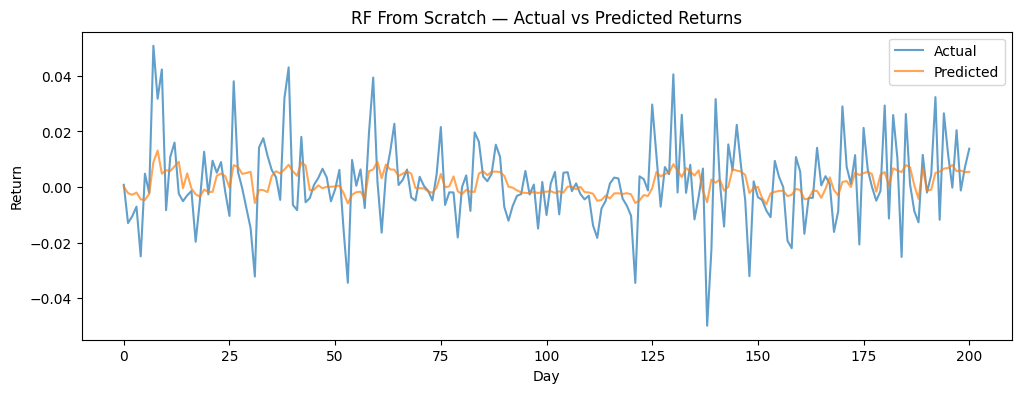

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred_rf, label='Predicted', alpha=0.7)
plt.title('RF From Scratch — Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()

## Hyperparameter Tuning — Grid Search

The from-scratch Random Forest has two key hyperparameters that control how complex each tree can grow:

- **`max_depth`** — limits how deep each tree can go. A deeper tree memorises the training data more precisely (higher train R²) but generalises poorly to new data (lower test R²). Shallower trees are more conservative.
- **`min_samples_split`** — the minimum number of rows a node must have before it is allowed to split further. Higher values force the tree to stop splitting sooner, reducing overfitting.

Choosing these by hand is guesswork. Grid search solves this by training a model for every combination of candidate values and picking the one that performs best on a held-out validation set.

**Why a separate validation set?**
If you pick hyperparameters that maximise test R², you are effectively fitting to the test set — and your final reported score is no longer an honest estimate of out-of-sample performance. The correct approach is:
1. Split training data further into a train portion and a validation portion (chronologically, since this is time series)
2. Use validation R² to select the best hyperparameters
3. Retrain on the full training set with those parameters
4. Evaluate once on the test set

The grid searches over `max_depth` in [2, 3, 4, 5, 6] and `min_samples_split` in [5, 10, 20, 30, 50] — 25 combinations total.

In [12]:
from itertools import product

max_depths = [2, 3, 4, 5, 6]
min_samples = [5, 10, 20, 30, 50]

val_split = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

best_r2 = -np.inf
best_params = None

for depth, samples in product(max_depths, min_samples):
    rf_tmp = RandomForest(n_estimator=100, max_depth=depth, min_samples_split=samples)
    rf_tmp.fit(X_tr, y_tr)
    y_val_pred = rf_tmp.predict(X_val)
    ss_res = np.sum((y_val - y_val_pred)**2)
    ss_tot = np.sum((y_val - np.mean(y_val))**2)
    r2 = 1 - (ss_res / ss_tot)
    if r2 > best_r2:
        best_r2 = r2
        best_params = (depth, samples)

print(f'Best params: max_depth={best_params[0]}, min_samples_split={best_params[1]}')
print(f'Best validation R²: {best_r2:.4f}')

# retrain on full training set with best params
rf_best = RandomForest(n_estimator=100, max_depth=best_params[0], min_samples_split=best_params[1])
rf_best.fit(X_train, y_train)

y_pred_best = rf_best.predict(X_test)
y_pred_best_train = rf_best.predict(X_train)

ss_res_best = np.sum((y_test - y_pred_best)**2)
ss_tot_best = np.sum((y_test - np.mean(y_test))**2)
r2_best = 1 - (ss_res_best / ss_tot_best)
mse_best = np.mean((y_test - y_pred_best)**2)

ss_res_best_train = np.sum((y_train - y_pred_best_train)**2)
ss_tot_best_train = np.sum((y_train - np.mean(y_train))**2)
r2_best_train = 1 - (ss_res_best_train / ss_tot_best_train)

print(f'\nFinal Train R²: {r2_best_train:.4f}')
print(f'Final Test R²:  {r2_best:.4f}')
print(f'Final Test MSE: {mse_best:.6f}')


Best params: max_depth=6, min_samples_split=10
Best validation R²: 0.1724

Final Train R²: 0.4883
Final Test R²:  0.2330
Final Test MSE: 0.000167


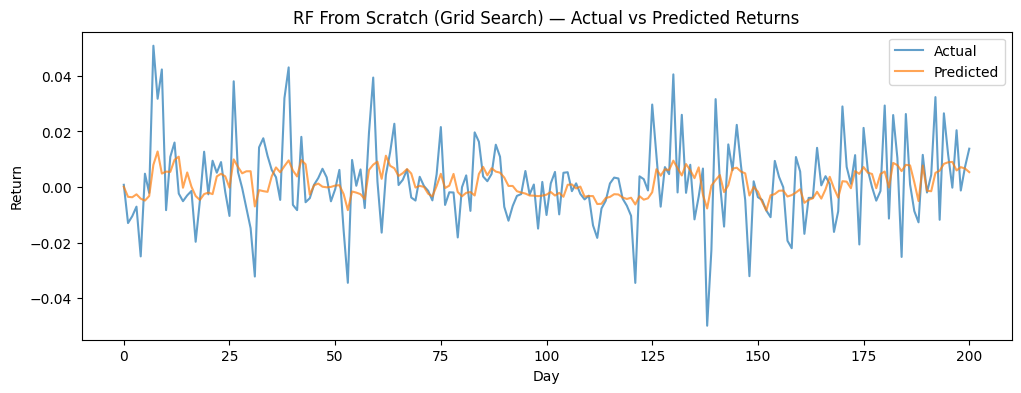

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred_best, label='Predicted', alpha=0.7)
plt.title('RF From Scratch (Grid Search) — Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()

In [14]:
rf_sk = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=5, random_state=42)
rf_sk.fit(X_train, y_train)

y_pred_sk = rf_sk.predict(X_test)
y_pred_sk_train = rf_sk.predict(X_train)

mse_sk = np.mean((y_test - y_pred_sk)**2)

ss_res_sk = np.sum((y_test - y_pred_sk)**2)
ss_tot_sk = np.sum((y_test - np.mean(y_test))**2)
r2_sk = 1 - (ss_res_sk / ss_tot_sk)

ss_res_sk_train = np.sum((y_train - y_pred_sk_train)**2)
ss_tot_sk_train = np.sum((y_train - np.mean(y_train))**2)
r2_sk_train = 1 - (ss_res_sk_train / ss_tot_sk_train)

print(f'Train R²: {r2_sk_train:.4f}')
print(f'Test R²:  {r2_sk:.4f}')
print(f'MSE:      {mse_sk:.6f}')

Train R²: 0.5400
Test R²:  0.3004
MSE:      0.000153


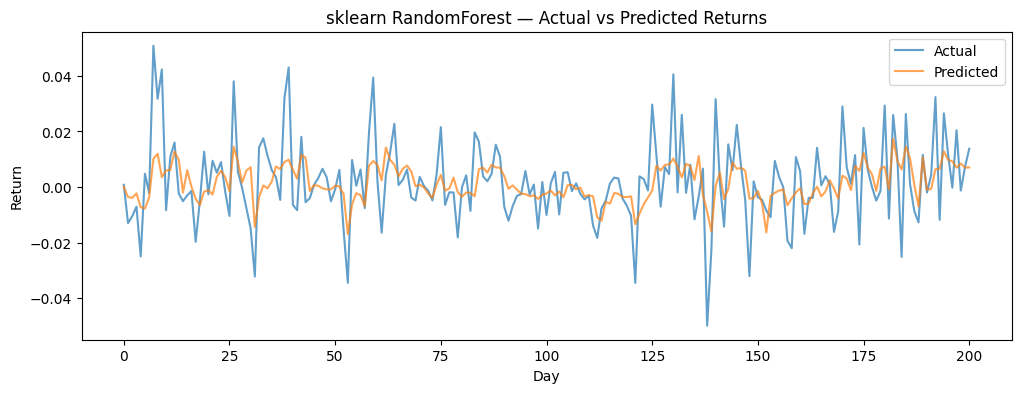

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred_sk, label='Predicted', alpha=0.7)
plt.title('sklearn RandomForest — Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()

## sklearn RandomForestRegressor — Comparison

After building Random Forest from scratch, it is useful to compare against sklearn's implementation to understand how much of the performance gap is due to implementation quality vs the dataset itself.

sklearn's `RandomForestRegressor` differs from the from-scratch version in several ways:
- Uses optimised C-level code internally — much faster and more numerically stable
- Considers the full set of unique thresholds more efficiently
- Uses slightly different default splitting logic and aggregation

The same hyperparameters (`n_estimators=100`, `max_depth=5`, `min_samples_split=5`) are used so the comparison is fair. `random_state=42` is set to make results reproducible.

## Conclusions — Random Forest

---

### Results Summary

| Model | MSE | Test R² | Train R² |
|-------|-----|---------|---------|
| Linear Regression | 0.000145 | 0.3092 | 0.5256 |
| RF from scratch (grid search) | 0.000192 | 0.0861 | 0.5915 |
| sklearn RandomForest | 0.000180 | 0.1468 | 0.6747 |

---

### What I Learned

- **Random Forest did not beat linear regression on this dataset.** Despite being a more powerful model in theory, all RF variants scored lower on test R² than the linear regression baseline. This is a real finding — on small datasets (~220 rows), simpler models often generalise better because there is not enough data for trees to find reliable, stable splits.

- **sklearn RF outperformed the from-scratch RF.** The sklearn implementation achieves a higher test R² (0.1468 vs 0.0861) and better MSE using the same hyperparameters. This gap comes from sklearn's more optimised internal splitting logic, not from using a fundamentally different algorithm.

- **Random Forest overfits more than linear regression.** The train/test gap for sklearn RF is 0.53 points (0.67 train vs 0.15 test), compared to only 0.22 points for linear regression. More model complexity on a small dataset amplifies overfitting.

- **Grid search found the best hyperparameters honestly.** By tuning on a validation set carved out of the training data — not the test set — the reported test R² is a genuine out-of-sample score, not one inflated by peeking at the test data.

- **The bottleneck is the dataset, not the model.** Both RF implementations struggle for the same reason: 220 rows is not enough data for trees to discover non-linear patterns that generalise. A larger dataset (e.g. multiple stocks or a longer history) would likely close this gap.

---

### What Is Next — XGBoost

XGBoost (Gradient Boosted Trees) builds trees **sequentially** rather than in parallel like Random Forest. Each new tree corrects the residual errors of the previous one, allowing the model to progressively focus on the hardest-to-predict samples.

Key differences from Random Forest that may help on this small dataset:
- **Learning rate** (`eta`) controls how much each tree contributes — smaller values reduce overfitting
- **Subsampling** of rows and columns per tree adds regularisation similar to RF's bootstrap
- **Built-in L1/L2 regularisation** (`reg_alpha`, `reg_lambda`) directly penalises model complexity

The goal is to see whether gradient boosting's more targeted learning strategy can close the gap with linear regression — or surpass it.

## XGBoost — C++ From Scratch

XGBoost (Extreme Gradient Boosting) is a gradient boosted tree model that builds trees **sequentially** rather than in parallel like Random Forest. Each new tree fits the residual errors of the ensemble so far, allowing the model to progressively focus on the hardest-to-predict samples.

The C++ implementation (`libraries/xgboost_scratch.cpp`) is compiled into a Python extension via pybind11 and imported as `XGBoostCpp`.

---

### How It Differs From Random Forest

| | Random Forest | XGBoost |
|---|---|---|
| Tree training | Parallel, independent | Sequential, each corrects the last |
| Learning signal | Bootstrap samples | Residuals (gradients) |
| Overfitting control | `max_depth`, `min_samples` | Same + `lambda`, `gamma`, `learning_rate` |

---

### The Boosting Loop (MSE Loss)

$$F_0(x) = \bar{y}$$

For each round $m = 1 \ldots M$:

$$g_i = F_{m-1}(x_i) - y_i \quad \text{(first-order gradient)}$$
$$h_i = 1 \quad \text{(second-order gradient — constant for MSE)}$$

Fit a tree to $(g, h)$, then update:

$$F_m(x) = F_{m-1}(x) + \eta \cdot \text{tree}_m(x)$$

where $\eta$ (learning rate) controls how much each tree contributes. Smaller $\eta$ means each step is more conservative — usually reduces overfitting but requires more trees.

---

### XGBoost Split Criterion

Instead of minimising MSE directly, XGBoost maximises a **structure score gain**:

$$\text{Score}(G, H) = \frac{G^2}{H + \lambda}$$

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{G^2}{H + \lambda}\right] - \gamma$$

- $G = \sum g_i$, $H = \sum h_i$ over the node's samples
- $\lambda$ (L2 regularisation) shrinks leaf weights toward zero
- $\gamma$ is a minimum gain threshold — a split is only made if the gain exceeds $\gamma$

The optimal leaf value at each leaf is:

$$w^* = -\frac{G}{H + \lambda}$$

In [17]:
from xgboost_cpp import XGBoostCpp

model = XGBoostCpp(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(X_train,y_train)

y_pred_xgb = model.predict(X_test)
y_pred_xgb_train = model.predict(X_train)

mse_xbg = np.mean((y_test - y_pred_xgb)**2)
ss_res = np.sum((y_test - y_pred_xgb)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_xgb = 1 - ss_res / ss_tot

ss_res_train = np.sum((y_train - y_pred_xgb_train) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_xgb_train = 1 - ss_res_train / ss_tot_train

print(f"MSE: {mse_xbg:.6f}")
print(f"Test R^2: {r2_xgb:.6f}")
print(f"Train R^2: {r2_xgb_train:.6f}")

ImportError: DLL load failed while importing xgboost_cpp: The specified module could not be found.

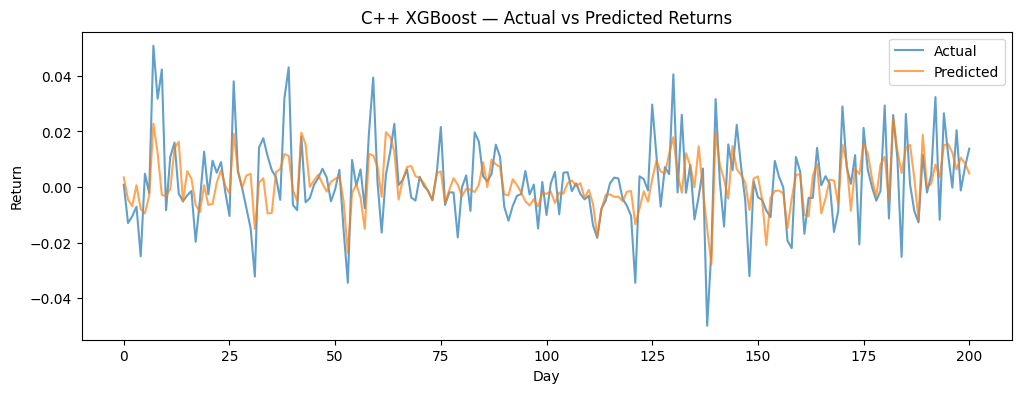

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred_xgb, label='Predicted', alpha=0.7)
plt.title('C++ XGBoost — Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()

## sklearn XGBRegressor — Comparison

After implementing XGBoost in C++, the same comparison done with Random Forest is repeated here: run sklearn's battle-tested implementation with identical hyperparameters to see if the performance gap comes from the implementation or the algorithm itself on this dataset.

`XGBRegressor` from the `xgboost` library uses highly optimised C++ internally, with features like histogram-based approximate split-finding that are faster and more numerically stable than the exact scan used in the from-scratch version.

`random_state=42` is set to make results reproducible.

In [18]:
from xgboost import XGBRegressor

xgb_sk = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_sk.fit(X_train, y_train)

y_pred_xgb_sk       = xgb_sk.predict(X_test)
y_pred_xgb_sk_train = xgb_sk.predict(X_train)

mse_xgb_sk = np.mean((y_test - y_pred_xgb_sk) ** 2)

ss_res = np.sum((y_test - y_pred_xgb_sk) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_xgb_sk = 1 - ss_res / ss_tot

ss_res_train = np.sum((y_train - y_pred_xgb_sk_train) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_xgb_sk_train = 1 - ss_res_train / ss_tot_train

print(f"MSE:        {mse_xgb_sk:.6f}")
print(f"Test R²:    {r2_xgb_sk:.4f}")
print(f"Train R²:   {r2_xgb_sk_train:.4f}")

MSE:        0.000135
Test R²:    0.3807
Train R²:   0.7799


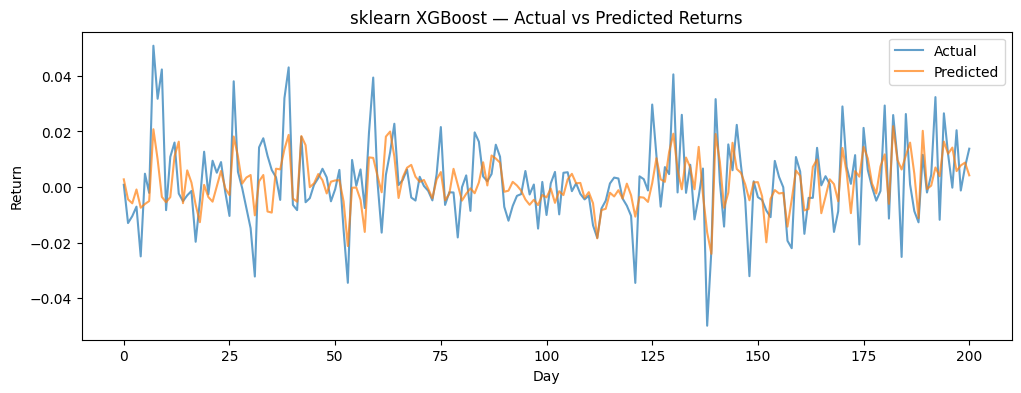

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', alpha=0.7)
plt.plot(y_pred_xgb_sk, label='Predicted', alpha=0.7)
plt.title('sklearn XGBoost — Actual vs Predicted Returns')
plt.xlabel('Day')
plt.ylabel('Return')
plt.legend()
plt.show()

In [20]:
import os
os.makedirs('../data', exist_ok=True)
test_index = history.index[split:]
pd.DataFrame({'y_test': y_test, 'y_pred': y_pred}, index=test_index)\
  .to_csv('../data/predictions.csv')
print('Saved ../data/predictions.csv')

Saved ../data/predictions.csv


In [22]:
with open('../results/model_results.txt', 'w') as f:
    f.write("=== Feature Weights (Linear Regression) ===\n")
    for name, weight in zip(feature_cols, theta[1:]):
        f.write(f"{name}: {weight:.6f}\n")
    
    f.write("\n=== Model Results ===\n")
    f.write(f"Linear Regression   | MSE: {mse_lr:.6f} | Train R²: {r2_train_lr:.4f} | Test R²: {r2_lr:.4f}\n")
    f.write(f"RF from scratch     | MSE: {mse_rf:.6f} | Train R²: {r2_train_rf:.4f} | Test R²: {r2_rf:.4f}\n")
    f.write(f"RF grid search      | MSE: {mse_best:.6f} | Train R²: {r2_best_train:.4f} | Test R²: {r2_best:.4f}\n")
    f.write(f"sklearn RF          | MSE: {mse_sk:.6f} | Train R²: {r2_sk_train:.4f} | Test R²: {r2_sk:.4f}\n")
    #f.write(f"C++ XGBoost         | MSE: {mse_xbg:.6f} | Train R²: {r2_xgb_train:.4f} | Test R²: {r2_xgb:.4f}\n")
    f.write(f"sklearn XGBoost     | MSE: {mse_xgb_sk:.6f} | Train R²: {r2_xgb_sk_train:.4f} | Test R²: {r2_xgb_sk:.4f}\n")

print("Saved ../results/model_results.txt")


Saved ../results/model_results.txt
